<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA3/TALLER3/E3_GraphNeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Machine Learning
**INTEGRANTES:**

Luis Alejandro Garzón Ramirez

Zorayda Acevedo Jimenez

Yulieth Danitza Aguillón Ortega



In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

In [ ]:
import torch
!pip install -q torch-scatter~=2.1.0 torch-sparse~=0.6.16 torch-cluster~=1.6.0 torch-spline-conv~=1.2.1 torch-geometric==2.2.0 -f https://data.pyg.org/whl/torch-{torch.__version__}.html

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 46.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 25.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.0/565.0 kB 19.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


## Facebook Page-Page dataset

This dataset was introduced by [Rozemberczki et al. in 2019](https://arxiv.org/abs/1909.13021). It was created using the Facebook Graph API in November 2017. In this dataset, each of the 22,470 nodes represents an official Facebook page. Pages are connected when there are mutual likes between them. Node features (128-dim vectors) are created from textual descriptions written by the owners of these pages. Our goal is to classify each node into one of four categories:

- politicians
- companies
- television shows
- governmental organizations.

The Facebook Page-Page dataset is similar to the previous one: it’s a social network with a node classification task. However, there are three major differences with Cora:

The number of nodes is much higher (2,708 versus 22,470)
The dimensionality of the node features decreased dramatically (from 1,433 to 128)
The goal is to classify each node into four categories instead of seven (which is easier since there are fewer options)
The following figure is a visualization of the dataset using Gephi. First, nodes with few connections have been filtered out to improve performance. The size of the remaining nodes depends on their number of connections, and their color indicates the category they belong to. Finally, two layouts have been applied: Fruchterman-Reingold and ForceAtlas2.

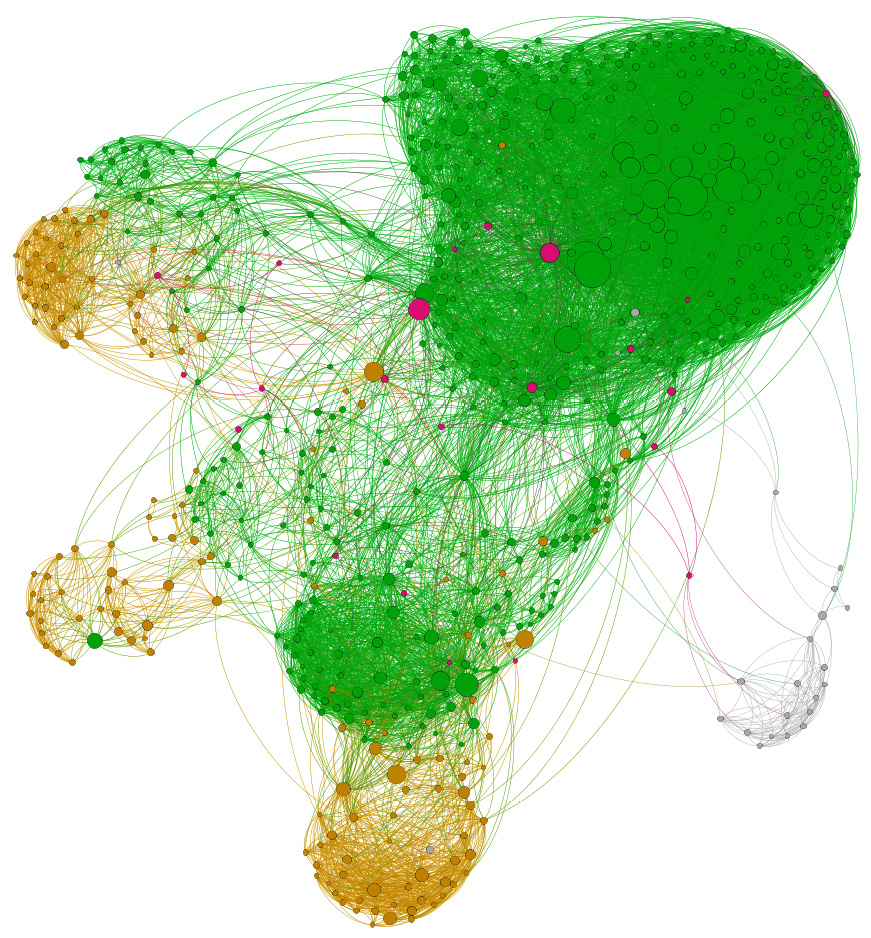

### Load dataset

In [ ]:
import torch
import logging

orig_torch_load = torch.load

def torch_wrapper(*args, **kwargs):
    logging.warning("[comfyui-unsafe-torch] I have unsafely patched `torch.load`.  The `weights_only` option of `torch.load` is forcibly disabled.")
    kwargs['weights_only'] = False

    return orig_torch_load(*args, **kwargs)

torch.load = torch_wrapper

NODE_CLASS_MAPPINGS = {}
__all__ = ['NODE_CLASS_MAPPINGS']

In [ ]:
from torch_geometric.datasets import FacebookPagePage

# Import dataset from PyTorch Geometric
dataset = FacebookPagePage(root=".")

data = dataset[0]

# Print information about the dataset
print(f'Dataset: {dataset}')
print('-----------------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

# Create masks
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

Processing...
Done!


Dataset: FacebookPagePage()
-----------------------
Number of graphs: 1
Number of nodes: 22470
Number of features: 128
Number of classes: 4

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True


## Visualizing the graph

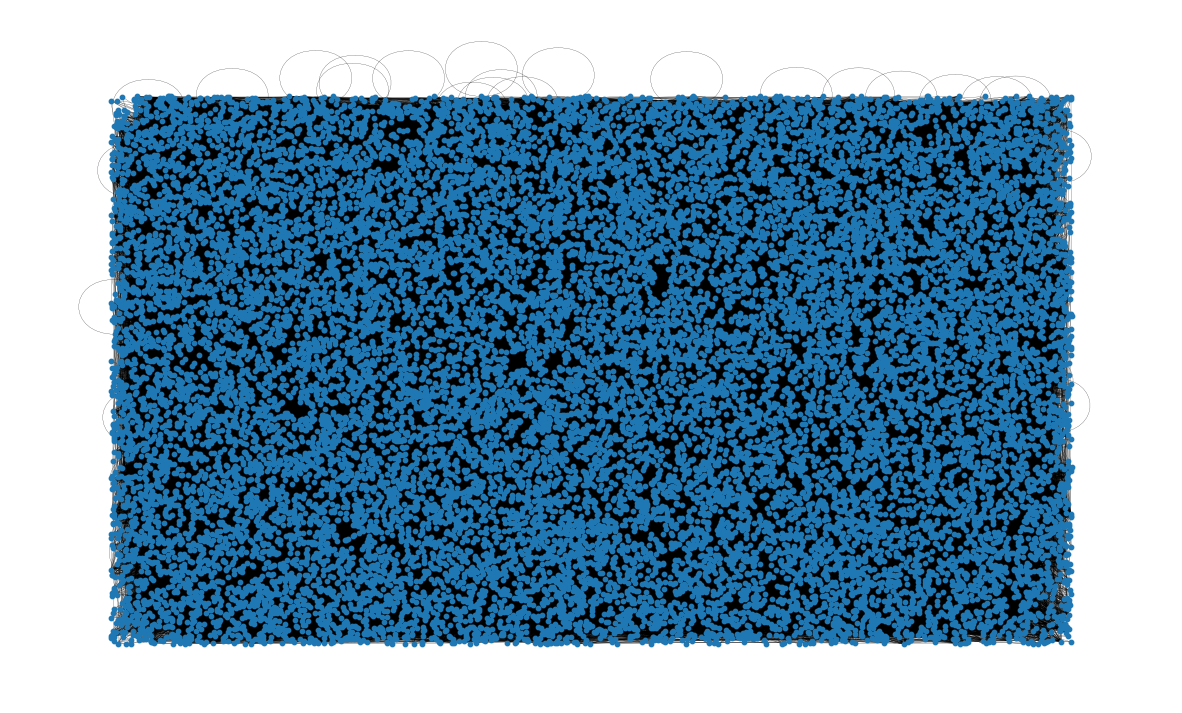

In [ ]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])
G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

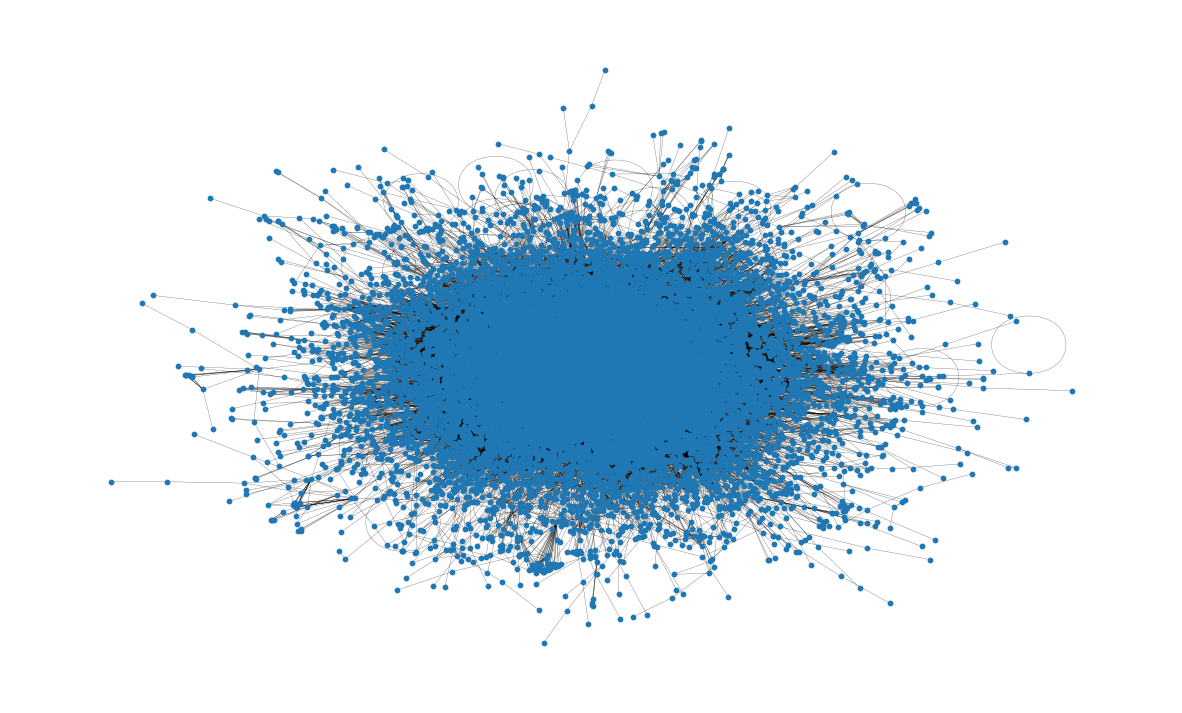

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

### Split dataset

In [ ]:
# Dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]
data.train_mask = range(18000)
data.val_mask = range(18001, 20000)
data.test_mask = range(20001, 22470)

### Build Adjacency Matrix

In [ ]:
from torch_geometric.utils import to_dense_adj
# Adjacency matrix
adjacency = to_dense_adj(data.edge_index)[0]
adjacency += torch.eye(len(adjacency))
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [ ]:
import torch
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F

def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

class SparseLayer(torch.nn.Module):
    def __init__(self, dim_in, dim_out):
        super().__init__()
        self.linear = Linear(dim_in, dim_out, bias=False)

    def forward(self, x, adjacency):
        x = self.linear(x)
        x = torch.sparse.mm(adjacency, x)
        return x


### Build MLP class

In [ ]:
df_x = pd.DataFrame(data.x.numpy())
df_x['label'] = pd.DataFrame(data.y)
df_x

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,label
0,-0.262576,-0.276483,-0.262350,-0.299327,-0.299159,-0.270681,-0.307757,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.223700,-0.284379,-0.224216,-0.209509,-0.255755,-0.215140,-0.375903,-0.223836,0
1,-0.262576,-0.276483,-0.262350,-0.299327,-0.299159,-0.270681,-0.307757,-0.269733,-0.25101,-0.308343,...,-0.234818,-0.223700,-0.284379,-0.197935,-0.147256,-0.255755,-0.215140,-0.364134,-0.128634,2
2,-0.262576,-0.265053,-0.262350,-0.299327,-0.299159,-0.270681,-0.307757,-0.210461,-0.25101,3.222161,...,-0.273229,-0.223700,-0.284379,-0.224216,-0.209509,-0.255755,-0.215140,-0.375903,-0.223836,1
3,-0.246378,-0.276483,-0.241991,-0.299327,-0.299159,-0.270681,-0.307051,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.223700,-0.265534,-0.080353,-0.209509,-0.250560,-0.180260,-0.375903,-0.223836,2
4,-0.262576,-0.276483,-0.262350,-0.299327,-0.299159,-0.270681,-0.307757,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.175312,-0.272613,-0.224216,-0.181153,-0.255755,-0.215140,-0.370639,-0.223836,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22465,-0.262576,-0.276483,-0.262350,-0.296955,-0.299159,-0.270681,-0.307757,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.223700,-0.284379,-0.224216,-0.209509,-0.255755,-0.196685,-0.370115,-0.223836,3
22466,-0.262576,-0.276483,-0.262350,-0.299327,-0.299159,-0.270681,-0.307757,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.221643,-0.284379,-0.224216,-0.209509,-0.255755,-0.215140,-0.375903,-0.223836,1
22467,-0.262576,-0.276483,-0.262350,-0.299327,-0.299159,-0.270681,-0.307757,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.223700,-0.284379,-0.224216,-0.146793,-0.255755,-0.180389,-0.372097,-0.222613,2
22468,-0.262576,-0.276483,-0.262350,-0.299327,-0.299159,-0.270681,-0.307668,-0.269733,-0.25101,-0.308343,...,-0.273229,-0.223700,-0.284379,-0.224216,-0.209509,-0.252456,-0.215140,-0.375903,-0.218148,1


In [ ]:
class MLP(torch.nn.Module):
    """Multilayer Perceptron"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.linear2 = Linear(dim_h, dim_out)

    def forward(self, x):
        x = self.linear1(x)
        x = torch.relu(x)
        x = self.linear2(x)
        return F.log_softmax(x, dim=1)

    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                          lr=0.01,
                                          weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [ ]:
# Create MLP model
mlp = MLP(dataset.num_features, 60, dataset.num_classes)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=60, bias=True)
  (linear2): Linear(in_features=60, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.390 | Train Acc: 25.93% | Val Loss: 1.39 | Val Acc: 25.41%
Epoch  20 | Train Loss: 0.585 | Train Acc: 77.11% | Val Loss: 0.63 | Val Acc: 75.19%
Epoch  40 | Train Loss: 0.519 | Train Acc: 79.55% | Val Loss: 0.60 | Val Acc: 75.39%
Epoch  60 | Train Loss: 0.474 | Train Acc: 81.75% | Val Loss: 0.60 | Val Acc: 76.09%
Epoch  80 | Train Loss: 0.433 | Train Acc: 83.61% | Val Loss: 0.62 | Val Acc: 76.29%
Epoch 100 | Train Loss: 0.404 | Train Acc: 84.36% | Val Loss: 0.63 | Val Acc: 76.09%

MLP test accuracy: 74.97%


### Build GNN class

In [ ]:
class GNN(torch.nn.Module):
    """Graph Neural Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = SparseLayer(dim_in, dim_h)
        self.gnn2 = SparseLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)


    def fit(self, data, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(),
                                      lr=0.01,
                                      weight_decay=5e-4)

        self.train()
        for epoch in range(epochs+1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data.train_mask], data.y[data.train_mask])
            acc = accuracy(out[data.train_mask].argmax(dim=1),
                          data.y[data.train_mask])
            loss.backward()
            optimizer.step()

            if(epoch % 20 == 0):
                val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
                val_acc = accuracy(out[data.val_mask].argmax(dim=1),
                                  data.y[data.val_mask])
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc:'
                      f' {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | '
                      f'Val Acc: {val_acc*100:.2f}%')

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x, adjacency)
        acc = accuracy(out.argmax(dim=1)[data.test_mask], data.y[data.test_mask])
        return acc

In [ ]:
gnn = GNN(dataset.num_features, 30, dataset.num_classes)
print(gnn)

# Train
gnn.fit(data, epochs=100)

# Test
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

GNN(
  (gnn1): SparseLayer(
    (linear): Linear(in_features=128, out_features=30, bias=False)
  )
  (gnn2): SparseLayer(
    (linear): Linear(in_features=30, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 123.054 | Train Acc: 25.27% | Val Loss: 129.81 | Val Acc: 25.06%
Epoch  20 | Train Loss: 10.288 | Train Acc: 81.79% | Val Loss: 6.79 | Val Acc: 83.34%
Epoch  40 | Train Loss: 7.159 | Train Acc: 83.92% | Val Loss: 4.52 | Val Acc: 84.59%
Epoch  60 | Train Loss: 2.149 | Train Acc: 85.59% | Val Loss: 1.83 | Val Acc: 86.69%
Epoch  80 | Train Loss: 1.259 | Train Acc: 86.49% | Val Loss: 1.21 | Val Acc: 85.99%
Epoch 100 | Train Loss: 0.834 | Train Acc: 85.52% | Val Loss: 0.83 | Val Acc: 85.34%

GNN test accuracy: 85.58%


### Run models and compare

In [ ]:
# MLP
mlp = MLP(dataset.num_features, 16, dataset.num_classes)
print(mlp)
mlp.fit(data, epochs=100)
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%\n')

# GCN
gnn = GNN(dataset.num_features, 16, dataset.num_classes)
print(gnn)
gnn.fit(data, epochs=100)
acc = gnn.test(data)
print(f'\nGNN test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=4, bias=True)
)
Epoch   0 | Train Loss: 1.427 | Train Acc: 24.17% | Val Loss: 1.43 | Val Acc: 23.46%
Epoch  20 | Train Loss: 0.687 | Train Acc: 73.07% | Val Loss: 0.70 | Val Acc: 72.39%
Epoch  40 | Train Loss: 0.579 | Train Acc: 77.13% | Val Loss: 0.61 | Val Acc: 75.14%
Epoch  60 | Train Loss: 0.548 | Train Acc: 78.21% | Val Loss: 0.60 | Val Acc: 76.39%
Epoch  80 | Train Loss: 0.530 | Train Acc: 78.94% | Val Loss: 0.59 | Val Acc: 76.29%
Epoch 100 | Train Loss: 0.517 | Train Acc: 79.72% | Val Loss: 0.59 | Val Acc: 76.64%

MLP test accuracy: 75.21%

GNN(
  (gnn1): SparseLayer(
    (linear): Linear(in_features=128, out_features=16, bias=False)
  )
  (gnn2): SparseLayer(
    (linear): Linear(in_features=16, out_features=4, bias=False)
  )
)
Epoch   0 | Train Loss: 99.850 | Train Acc: 28.02% | Val Loss: 96.74 | Val Acc: 26.91%
Epoch  20 | Train Loss: 8.956 | Train Acc: 74.7

Vemos que GNN es aproximadamente 10 puntos porcentuales superior en rendimiento medido por accuracy, hasta este punto seria el modelo a utilizar para el problema de negocio

### Split dataset
User a pytorch random split and debug model classes...

In [ ]:
# Obtener índices aleatorios
indices = torch.randperm(data.num_nodes)
train_size = int(0.8 * data.num_nodes)
train_idx = indices[:train_size]
test_idx = indices[train_size:]

# Crear máscaras manualmente
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

data.train_mask[train_idx] = True
data.test_mask[test_idx] = True

# Dividir aún más si quieres validación
val_size = int(0.1 * data.num_nodes)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask[train_idx[:val_size]] = True
data.train_mask[train_idx[:val_size]] = False  # Quitar de train los val


### Build MLP class

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.datasets import FacebookPagePage

# Definir la clase MLP
class MLP(nn.Module):
    def __init__(self, in_features, hidden_units, out_features):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_units)
        self.fc2 = nn.Linear(hidden_units, out_features)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x  # Los logits se pasan directamente (CrossEntropy incluye softmax)

# Fijar la semilla
torch.manual_seed(42)

# Cargar el dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]

# División aleatoria
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

train_idx, val_idx, test_idx = torch.split(indices, [train_size, val_size, test_size])

# Crear máscaras de entrenamiento, validación y prueba
data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True

data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[val_idx] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True

# Validación de no solapamiento
assert (data.train_mask & data.val_mask).sum().item() == 0, "Train y Val se solapan"
assert (data.train_mask & data.test_mask).sum().item() == 0, "Train y Test se solapan"
assert (data.val_mask & data.test_mask).sum().item() == 0, "Val y Test se solapan"

# Inicializar modelo, criterio y optimizador
input_dim = dataset.num_features
hidden_dim = 64
output_dim = dataset.num_classes

model = MLP(input_dim, hidden_dim, output_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Función de entrenamiento
def train(model, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x)  # MLP no usa edge_index
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Función de evaluación
def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

# Entrenar el modelo
num_epochs = 100
for epoch in range(1, num_epochs + 1):
    loss = train(model, data)
    train_acc = evaluate(model, data, data.train_mask)
    val_acc = evaluate(model, data, data.val_mask)
    print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

# Evaluación final en el conjunto de prueba
test_acc = evaluate(model, data, data.test_mask)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")


Epoch 001 | Loss: 1.4461 | Train Acc: 20.61% | Val Acc: 19.80%
Epoch 002 | Loss: 1.4221 | Train Acc: 24.51% | Val Acc: 23.23%
Epoch 003 | Loss: 1.3991 | Train Acc: 29.42% | Val Acc: 27.81%
Epoch 004 | Loss: 1.3772 | Train Acc: 34.52% | Val Acc: 33.24%
Epoch 005 | Loss: 1.3562 | Train Acc: 39.46% | Val Acc: 38.76%
Epoch 006 | Loss: 1.3361 | Train Acc: 43.31% | Val Acc: 42.55%
Epoch 007 | Loss: 1.3169 | Train Acc: 46.19% | Val Acc: 45.66%
Epoch 008 | Loss: 1.2984 | Train Acc: 47.98% | Val Acc: 47.62%
Epoch 009 | Loss: 1.2807 | Train Acc: 49.33% | Val Acc: 48.55%
Epoch 010 | Loss: 1.2636 | Train Acc: 50.19% | Val Acc: 49.18%
Epoch 011 | Loss: 1.2471 | Train Acc: 51.01% | Val Acc: 50.24%
Epoch 012 | Loss: 1.2312 | Train Acc: 51.37% | Val Acc: 50.60%
Epoch 013 | Loss: 1.2158 | Train Acc: 51.90% | Val Acc: 51.13%
Epoch 014 | Loss: 1.2008 | Train Acc: 52.28% | Val Acc: 51.49%
Epoch 015 | Loss: 1.1862 | Train Acc: 52.60% | Val Acc: 52.20%
Epoch 016 | Loss: 1.1721 | Train Acc: 52.97% | Val Acc:

### Build GNN class

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import GCNConv
from torch_geometric.datasets import FacebookPagePage

# Definir el modelo GNN
class GNN(nn.Module):
    def __init__(self, in_features, hidden_units, out_features):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_features, hidden_units)
        self.conv2 = GCNConv(hidden_units, out_features)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):
        x = self.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# Fijar semilla para reproducibilidad
torch.manual_seed(42)

# Cargar dataset
dataset = FacebookPagePage(root=".")
data = dataset[0]

# Dividir los nodos en train/val/test
num_nodes = data.num_nodes
indices = torch.randperm(num_nodes)

train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)
test_size = num_nodes - train_size - val_size

train_idx, val_idx, test_idx = torch.split(indices, [train_size, val_size, test_size])

# Crear máscaras
data.train_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True

data.val_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.val_mask[val_idx] = True

data.test_mask = torch.zeros(num_nodes, dtype=torch.bool)
data.test_mask[test_idx] = True

# Validación de no solapamiento
assert (data.train_mask & data.val_mask).sum().item() == 0, "Train y Val se solapan"
assert (data.train_mask & data.test_mask).sum().item() == 0, "Train y Test se solapan"
assert (data.val_mask & data.test_mask).sum().item() == 0, "Val y Test se solapan"

# Inicializar modelo, pérdida y optimizador
gnn = GNN(in_features=dataset.num_features, hidden_units=64, out_features=dataset.num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gnn.parameters(), lr=0.01)

# Función de entrenamiento
def train(model, data):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Función de evaluación
def evaluate(model, data, mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        correct = (pred[mask] == data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
    return acc

# Entrenar el modelo
num_epochs = 100
for epoch in range(1, num_epochs + 1):
    loss = train(gnn, data)
    train_acc = evaluate(gnn, data, data.train_mask)
    val_acc = evaluate(gnn, data, data.val_mask)
    print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

# Evaluar el modelo en el conjunto de prueba
test_acc = evaluate(gnn, data, data.test_mask)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")


Epoch 001 | Loss: 1.4610 | Train Acc: 57.12% | Val Acc: 56.56%
Epoch 002 | Loss: 1.1492 | Train Acc: 66.45% | Val Acc: 66.58%
Epoch 003 | Loss: 0.9417 | Train Acc: 71.65% | Val Acc: 71.16%
Epoch 004 | Loss: 0.8029 | Train Acc: 75.03% | Val Acc: 74.59%
Epoch 005 | Loss: 0.7055 | Train Acc: 77.45% | Val Acc: 77.08%
Epoch 006 | Loss: 0.6319 | Train Acc: 79.73% | Val Acc: 78.68%
Epoch 007 | Loss: 0.5737 | Train Acc: 81.62% | Val Acc: 80.73%
Epoch 008 | Loss: 0.5268 | Train Acc: 83.47% | Val Acc: 82.51%
Epoch 009 | Loss: 0.4891 | Train Acc: 84.49% | Val Acc: 83.67%
Epoch 010 | Loss: 0.4586 | Train Acc: 85.50% | Val Acc: 84.51%
Epoch 011 | Loss: 0.4335 | Train Acc: 86.30% | Val Acc: 85.58%
Epoch 012 | Loss: 0.4123 | Train Acc: 86.82% | Val Acc: 86.34%
Epoch 013 | Loss: 0.3944 | Train Acc: 87.36% | Val Acc: 86.56%
Epoch 014 | Loss: 0.3790 | Train Acc: 87.81% | Val Acc: 87.09%
Epoch 015 | Loss: 0.3658 | Train Acc: 88.23% | Val Acc: 87.72%
Epoch 016 | Loss: 0.3543 | Train Acc: 88.43% | Val Acc:

### Run and compare models

Vemos que GNN vuelve a presentar mejor rendimiento, siendo su accuracy 93% es aproximadamente 20 porcentuales superior en rendimiento al de MLP que es 73% disminuyendo este ultimo su rendimiento en esta etapa.